# End-to-End ML Pipelines — Reference Notebook

Companion to `ml_cheatsheet.ipynb`.

**Division of labour between the two notebooks:**

| Notebook | Answers |
|---|---|
| `ml_cheatsheet.ipynb` | *What is this algorithm and how does it work?* |
| `ml_pipelines.ipynb` (this one) | *In what order do I do things, and what does the glue look like?* |

This notebook deliberately does **not** explain algorithms. Each pipeline is one
continuous code cell from `pd.read_csv()` to interpretation, so the whole arc is
visible without scrolling through prose. Parameter explanations live in inline
comments.

---

## 00 — Which pipeline do I reach for?

| My situation | Pipeline | Model families to try first |
|---|---|---|
| Target is a number | 1 — Regression | Ridge -> RandomForest -> XGBoost |
| Target is a category, classes roughly balanced | 2 — Classification | LogisticRegression -> RandomForest |
| Target is a category, one class is rare (<10%) | 3 — Imbalanced | class_weight / SMOTE + XGBoost |
| Features far outnumber samples | 4 — High-dimensional | VarianceThreshold + PCA + linear model |
| No target at all, want groups | 5 — Clustering | KMeans, DBSCAN |
| No target, want to flag rare weird rows | 6 — Anomaly detection | IsolationForest, LOF |

**Two questions settle it almost every time:** do I have a labelled target, and if so
is it a number or a category? Everything after that is a refinement based on class
balance and feature-to-sample ratio.

---

## Datasets used

| Pipeline | Dataset | Source |
|---|---|---|
| 1, 5 | Singapore HDB resale | data.gov.sg |
| 2 | Titanic | seaborn built-in |
| 3, 4, 6 | UCI SECOM | archive.ics.uci.edu |

Set the paths in section 01 to match your local `data/` folder.

---

## 01 — Imports and paths

Run this once. Every pipeline below depends on it.

In [1]:
# ---- Core -------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Preprocessing ----------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

# ---- Model selection --------------------------------------------------------
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV,
)

# ---- Models -----------------------------------------------------------------
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier, IsolationForest,
)
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
import xgboost as xgb
         
# ---- Metrics ----------------------------------------------------------------
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, silhouette_score,
)
from sklearn.inspection import permutation_importance

# ---- Config -----------------------------------------------------------------
RANDOM_STATE = 42          # set everywhere so results are reproducible
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# ---- Paths (edit to match your repo) ----------------------------------------
HDB_PATH   = "/Users/cheerupdimbo/Documents/ds-sprint-july/ds-sprint-july/projects/projects1_hdb/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
SECOM_PATH = "/Users/cheerupdimbo/Documents/ds-sprint-july/ds-sprint-july/projects/projects2_secom/uci-secom.csv"


`imbalanced-learn` is only needed for Pipeline 3. Import it there so the rest of the
notebook still runs if the package is missing.

---

# Pipeline 1 — Regression (HDB resale price)

## When to use

| Signal | Reading |
|---|---|
| Target is continuous (price, yield, thickness, cycle time) | Regression |
| Mix of numeric and categorical predictors | Needs `ColumnTransformer` |
| Rows are independent | Plain `KFold` is fine; use `TimeSeriesSplit` if forecasting forward in time |

**Red flag:** if the target is a count that is mostly zeros, or is bounded 0–1, plain
linear regression will misbehave. That is a different model family, not a different
pipeline.

## The shape of the code below

`read` -> `feature engineering` -> `split` -> `ColumnTransformer` -> `baseline` ->
`compare models` -> `tune the winner` -> `evaluate on test` -> `interpret`

The split happens **before** any imputing or scaling. That ordering is the single most
important line in the cell.

(234672, 11)
month                      str
town                       str
flat_type                  str
block                      str
street_name                str
storey_range               str
floor_area_sqm         float64
flat_model                 str
lease_commence_date      int64
remaining_lease            str
resale_price           float64
dtype: object
train=(187737, 7)  test=(46935, 7)
Ridge baseline RMSE: 69,304 (+/- 310)
ridge  RMSE     69,304  (+/- 310)
rf     RMSE     39,237  (+/- 281)
xgb    RMSE     39,900  (+/- 212)
Fitting 5 folds for each of 48 candidates, totalling 240 fits
best CV RMSE: 36,017
best params : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__n_estimators': 600, 'model__subsample': 0.8}
RMSE : 36,020
MAE  : 25,796
R2   : 0.965


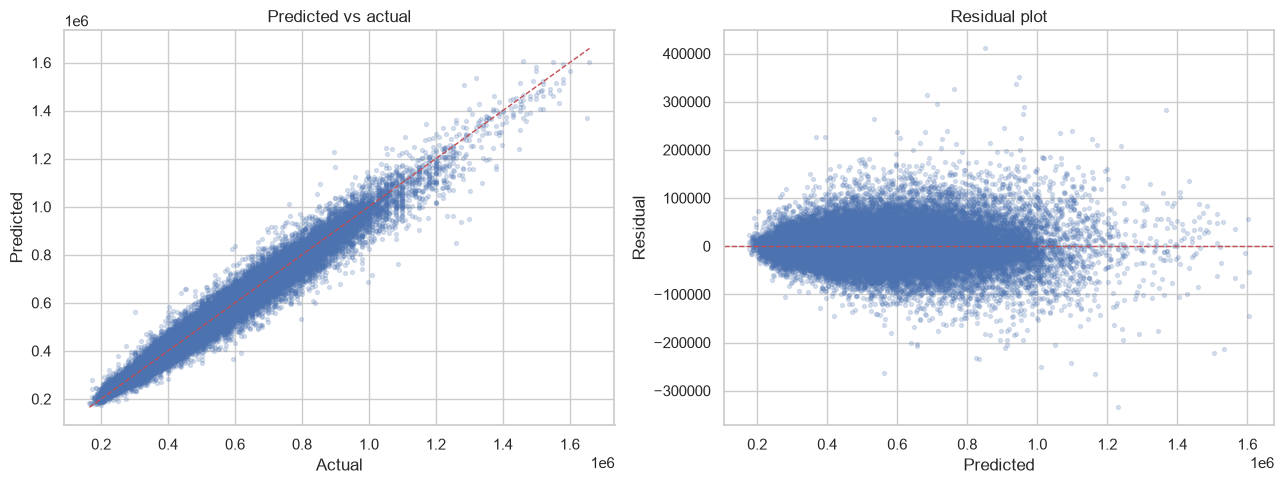

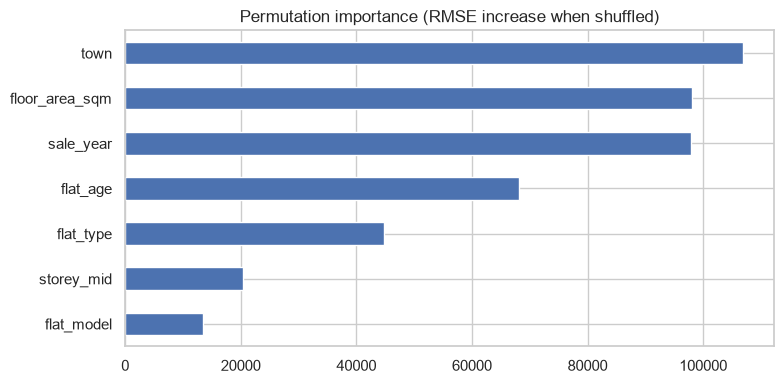

In [ ]:
# =============================================================================
# PIPELINE 1 — REGRESSION: predicting HDB resale price
# =============================================================================

# ---- 1. Load ----------------------------------------------------------------
HDB_PATH = "/Users/cheerupdimbo/Documents/ds-sprint-july/ds-sprint-july/projects/projects1_hdb/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
df = pd.read_csv(HDB_PATH)
print(df.shape)
print(df.dtypes)
df.head()

# ---- 2. Feature engineering -------------------------------------------------
# Raw columns are not model-ready. Two derived features do most of the work here.
df["month"] = pd.to_datetime(df["month"])
df["sale_year"] = df["month"].dt.year
df["flat_age"] = df["sale_year"] - df["lease_commence_date"]

# "storey_range" arrives as text like "10 TO 12" -> take the midpoint as a number.
storey_bounds = df["storey_range"].str.extract(r"(\d+)\s+TO\s+(\d+)").astype(float)
df["storey_mid"] = storey_bounds.mean(axis=1)

# ---- 3. Define X and y ------------------------------------------------------
TARGET = "resale_price"
num_features = ["floor_area_sqm", "flat_age", "storey_mid", "sale_year"]
cat_features = ["town", "flat_type", "flat_model"]

X = df[num_features + cat_features]
y = df[TARGET]

# ---- 4. Split FIRST, before any fitting -------------------------------------
# Anything learned from the data (medians, category lists, scaling stats) must be
# learned from the training set only. Splitting later leaks test information.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"train={X_train.shape}  test={X_test.shape}")

# ---- 5. Preprocessing: one transformer per column type ----------------------
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # median resists outliers
    ("scale",  StandardScaler()),                   # impute BEFORE scale: NaNs break the scaler
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # handle_unknown="ignore": a town seen only in test becomes all-zeros
    # instead of raising an error at predict time
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe,     num_features),
    ("cat", categorical_pipe, cat_features),
])

# ---- 6. Baseline: always establish one before tuning anything ---------------
baseline = Pipeline([
    ("prep", preprocessor), 
    ("model", Ridge(alpha=1.0))
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# sklearn maximises scores, so error metrics are returned negative. Flip the sign.
rmse_cv = -cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error"
)
print(f"Ridge baseline RMSE: {rmse_cv.mean():,.0f} (+/- {rmse_cv.std():,.0f})")

# ---- 7. Compare model families before tuning any single one -----------------
candidates = {
    "ridge": Ridge(alpha=1.0),
    "rf":    RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "xgb":   xgb.XGBRegressor(
                 n_estimators=400, learning_rate=0.1, max_depth=6,
                 random_state=RANDOM_STATE, n_jobs=-1,
             ),
}

for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = -cross_val_score(
        pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error"
    )
    print(f"{name:6s} RMSE {scores.mean():>10,.0f}  (+/- {scores.std():,.0f})")

# ---- 8. Tune the winner -----------------------------------------------------
# "model__" prefix reaches inside the pipeline step named "model".
param_grid = {
    "model__max_depth":        [4, 6, 8],
    "model__learning_rate":    [0.05, 0.1],
    "model__n_estimators":     [300, 600],
    "model__subsample":        [0.8, 1.0],   # row sampling, fights overfitting
    "model__colsample_bytree": [0.8, 1.0],   # column sampling, same purpose
}

search = GridSearchCV(
    Pipeline([("prep", preprocessor), ("model", candidates["xgb"])]),
    param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    refit=True,   # refits the best config on all training data automatically
)
search.fit(X_train, y_train)

print(f"best CV RMSE: {-search.best_score_:,.0f}")
print(f"best params : {search.best_params_}")
best_model = search.best_estimator_

# ---- 9. Evaluate on the held-out test set — once, at the end ----------------
y_pred = best_model.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
print(f"R2   : {r2_score(y_test, y_pred):.3f}")

# ---- 10. Interpret ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual: points should hug the diagonal
axes[0].scatter(y_test, y_pred, alpha=0.2, s=8)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set(xlabel="Actual", ylabel="Predicted", title="Predicted vs actual")

# Residuals vs predicted: look for a shapeless cloud centred on zero
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.2, s=8)
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set(xlabel="Predicted", ylabel="Residual", title="Residual plot")
plt.tight_layout(); plt.show()

# Permutation importance: shuffle one column, measure how much performance drops.
# Model-agnostic and computed on held-out data, unlike tree .feature_importances_.
perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=10,
    random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error", n_jobs=-1,
)
imp = (pd.Series(perm.importances_mean, index=X_test.columns)
         .sort_values(ascending=False))

plt.figure(figsize=(8, 4))
imp.head(10).plot(kind="barh").invert_yaxis()
plt.title("Permutation importance (RMSE increase when shuffled)")
plt.tight_layout(); plt.show()

## Reading the output

| Metric | Reading |
|---|---|
| RMSE | Same units as the target. Punishes large errors heavily. The default report metric. |
| MAE | Typical error size in target units. Less sensitive to a few big misses. |
| R² | Share of variance explained. Compares models on the same target only — never across datasets. |

**Diagnostics:**

- **Residual funnel** (spread widening with predicted value) — variance is not constant.
  Try modelling `log(price)` instead, then exponentiate predictions back.
- **Curved residuals** — a relationship the model has not captured. Add an interaction
  or a non-linear term.
- **Train RMSE far below CV RMSE** — overfitting. Reduce `max_depth`, lower
  `n_estimators`, or increase regularisation.

**Gotcha:** `permutation_importance` on the *training* set flatters the model. Always
compute it on held-out data, as above.

---

# Pipeline 2 — Binary classification, balanced (Titanic)

## When to use

| Signal | Reading |
|---|---|
| Target is a category | Classification |
| Minority class is roughly 30–50% | Accuracy is meaningful; ROC-AUC is a fair summary |
| You want probabilities, not just labels | Use `.predict_proba()` and tune the threshold |

**The one structural difference from Pipeline 1:** every split must be *stratified*, so
the class ratio is preserved in each fold. `StratifiedKFold` and
`train_test_split(..., stratify=y)` handle this.

(891, 15)
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
logreg  acc 0.796 | f1 0.723 | auc 0.856
rf      acc 0.798 | f1 0.729 | auc 0.862
xgb     acc 0.810 | f1 0.750 | auc 0.879
best CV AUC: 0.877  {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
              precision    recall  f1-score   support

        died       0.80      0.92      0.85       110
    survived       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179

ROC-AUC: 0.836


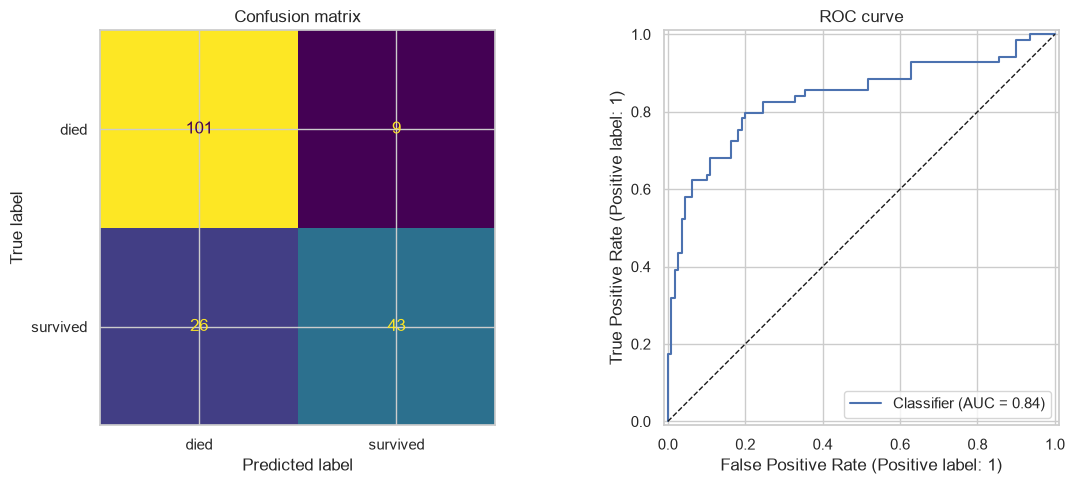

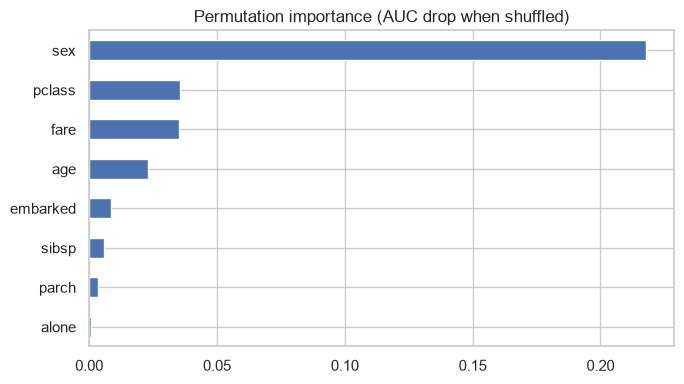

In [3]:
# =============================================================================
# PIPELINE 2 — BINARY CLASSIFICATION (balanced): Titanic survival
# =============================================================================

# ---- 1. Load ----------------------------------------------------------------
# Needs internet the first time. Offline: pd.read_csv("data/titanic.csv")
df = sns.load_dataset("titanic")
print(df.shape)
print(df["survived"].value_counts(normalize=True))   # ~62/38 — comfortably balanced

# ---- 2. Define X and y ------------------------------------------------------
TARGET = "survived"
num_features = ["age", "fare", "sibsp", "parch"]
cat_features = ["pclass", "sex", "embarked", "alone"]

X = df[num_features + cat_features]
y = df[TARGET]

# ---- 3. Stratified split ----------------------------------------------------
# stratify=y keeps the 62/38 ratio in both halves. Without it, a lucky split can
# hand you a test set with a different class balance and misleading metrics.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# ---- 4. Preprocessing -------------------------------------------------------
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),      # essential for LogisticRegression
    ]), num_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), cat_features),
])

# ---- 5. Baseline + comparison -----------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "logreg": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "rf":     RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "xgb":    xgb.XGBClassifier(
                  n_estimators=300, learning_rate=0.1, max_depth=4,
                  eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
              ),
}

for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    # cross_validate returns several metrics in one pass over the folds
    res = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=["accuracy", "f1", "roc_auc"], n_jobs=-1,
    )
    print(f"{name:7s} acc {res['test_accuracy'].mean():.3f} | "
          f"f1 {res['test_f1'].mean():.3f} | auc {res['test_roc_auc'].mean():.3f}")

# ---- 6. Tune ----------------------------------------------------------------
param_grid = {
    "model__n_estimators":     [200, 400],
    "model__max_depth":        [3, 5, None],
    "model__min_samples_leaf": [1, 2, 4],   # larger leaves = smoother, less overfit
}

search = GridSearchCV(
    Pipeline([("prep", preprocessor), ("model", candidates["rf"])]),
    param_grid, cv=cv, scoring="roc_auc", n_jobs=-1,
)
search.fit(X_train, y_train)
print(f"best CV AUC: {search.best_score_:.3f}  {search.best_params_}")
best_model = search.best_estimator_

# ---- 7. Evaluate ------------------------------------------------------------
y_pred  = best_model.predict(X_test)                  # labels at the 0.5 threshold
y_proba = best_model.predict_proba(X_test)[:, 1]      # column 1 = P(class 1) = P(survived)

print(classification_report(y_test, y_pred, target_names=["died", "survived"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["died", "survived"], ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=1)   # diagonal = random guessing
axes[1].set_title("ROC curve")
plt.tight_layout(); plt.show()

# ---- 8. Interpret -----------------------------------------------------------
perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=10,
    random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1,
)
(pd.Series(perm.importances_mean, index=X_test.columns)
   .sort_values().plot(kind="barh", figsize=(7, 4)))
plt.title("Permutation importance (AUC drop when shuffled)")
plt.tight_layout(); plt.show()

## Reading the output

| Metric | Question it answers |
|---|---|
| Accuracy | Of all predictions, how many were right? Trustworthy **only** when classes are balanced. |
| Precision | Of everything I flagged positive, how much really was? |
| Recall | Of all the real positives, how many did I catch? |
| F1 | Harmonic mean of precision and recall — one number when both matter. |
| ROC-AUC | Probability a random positive is ranked above a random negative. Threshold-free. |

**Confusion matrix orientation in sklearn** — rows are true, columns are predicted:

| | Pred 0 | Pred 1 |
|---|---|---|
| **True 0** | TN | FP |
| **True 1** | FN | TP |

**Gotcha:** `.predict()` silently applies a 0.5 threshold. That is a business decision,
not a statistical one. If a false negative costs more than a false positive, move the
threshold — see Pipeline 3.

---

# Pipeline 3 — Imbalanced classification (SECOM defect prediction)

## When to use

| Signal | Reading |
|---|---|
| Minority class under ~10% | Accuracy becomes meaningless — predicting all-majority scores well |
| The rare class is the one you care about | Optimise recall or average precision, never accuracy |
| Cost of a miss ≠ cost of a false alarm | The decision threshold must be tuned deliberately |

SECOM is ~6.6% fail. A model that predicts "pass" for every wafer scores 93% accuracy
and is worthless.

## Three levers, and what each actually does

| Lever | Mechanism | Trade-off |
|---|---|---|
| `class_weight="balanced"` | Errors on the rare class cost more in the loss function | Free, no new data, always try first |
| `scale_pos_weight` (XGBoost) | Same idea, XGBoost's own parameter. Set to `n_neg / n_pos` | Same |
| SMOTE | Synthesises new minority rows by interpolating between neighbours | Can invent implausible rows; **must** sit inside the CV fold |

**The SMOTE trap:** resampling before splitting leaks synthetic rows derived from test
data into training. `imblearn.pipeline.Pipeline` resamples training folds only — that is
why the cell below imports `Pipeline` from `imblearn`, not `sklearn`.

## Metric choice

Use **average precision** (area under the PR curve), not ROC-AUC. With a rare positive
class, ROC-AUC looks flattering because the huge true-negative count dominates the false
positive rate.

(1567, 592)
X: (1567, 590)   fail rate: 6.637%
Pass/Fail
0    1463
1     104
Name: count, dtype: int64
after cleaning: (1567, 446)
train fails: 83  test fails: 21
logreg_weighted  AP 0.168 | recall 0.265 | auc 0.617
rf_weighted      AP 0.202 | recall 0.000 | auc 0.696
xgb_scaled       AP 0.181 | recall 0.037 | auc 0.672
smote_xgb        AP 0.165 | recall 0.035 | auc 0.665
Fitting 5 folds for each of 30 candidates, totalling 150 fits
best CV AP: 0.207  {'model__subsample': 0.6, 'model__n_estimators': 900, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.3}
best threshold: 0.018  (default is 0.5)
  -> precision 0.220, recall 0.524

--- default 0.5 threshold ---
              precision    recall  f1-score   support

        pass       0.93      1.00      0.96       293
        fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       3

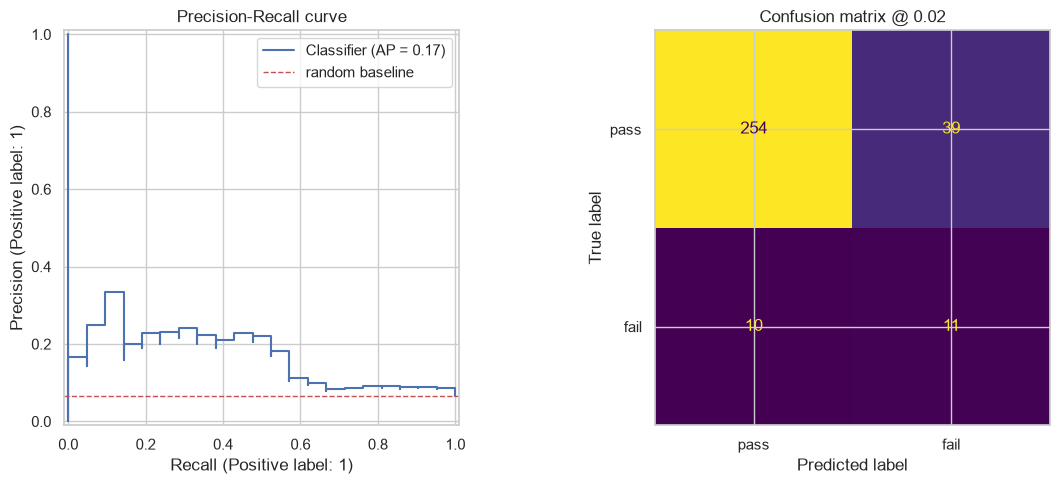

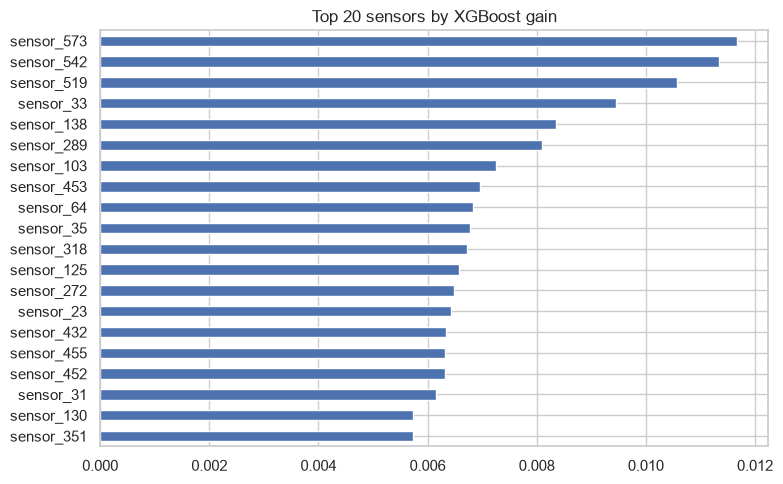

In [5]:
# =============================================================================
# PIPELINE 3 — IMBALANCED CLASSIFICATION: SECOM pass/fail
# =============================================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline   # NOT sklearn's Pipeline

# ---- 1. Load ----------------------------------------------------------------
df_secom = pd.read_csv(SECOM_PATH)
print(df_secom.shape)
df_secom.head()

# Split into time, features, target. Sensor columns are everything except
# Time and Pass/Fail, whatever they happen to be named or numbered.
non_feature_cols = ["Time", "Pass/Fail"]
sensor_cols = [c for c in df_secom.columns if c not in non_feature_cols]

X_raw = df_secom[sensor_cols].copy()
X_raw.columns = [f"sensor_{i}" for i in range(X_raw.shape[1])]

# Original labels: -1 = pass, 1 = fail. Map to 0/1 so "1" is the event of interest.
y = (df_secom["Pass/Fail"] == 1).astype(int)

print(f"X: {X_raw.shape}   fail rate: {y.mean():.3%}")
print(y.value_counts())

# ---- 2. Column-level cleaning (before splitting — see note below) ------------
missing_frac = X_raw.isna().mean()
X_clean = X_raw.loc[:, missing_frac < 0.5]            # drop mostly-empty sensors
X_clean = X_clean.loc[:, X_clean.nunique(dropna=True) > 1]   # drop constant sensors
print(f"after cleaning: {X_clean.shape}")

# ---- 3. Stratified split ----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"train fails: {y_train.sum()}  test fails: {y_test.sum()}")

# ---- 4. Preprocessing — all numeric here, so no ColumnTransformer needed ----
preprocessor = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])

# ---- 5. Compare the three imbalance strategies ------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

strategies = {
    "logreg_weighted": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "rf_weighted": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400, class_weight="balanced_subsample",
            random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "xgb_scaled": Pipeline([
        ("prep", preprocessor),
        ("model", xgb.XGBClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=4,
            scale_pos_weight=neg / pos,     # the XGBoost equivalent of class_weight
            eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    # imblearn's Pipeline does not allow a nested Pipeline as a step, so the
    # impute/scale steps are inlined here instead of reusing `preprocessor`.
    "smote_xgb": ImbPipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
        ("smote",  SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model",  xgb.XGBClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=4,
            eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

for name, pipe in strategies.items():
    res = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=["average_precision", "recall", "roc_auc"], n_jobs=-1,
    )
    print(f"{name:16s} AP {res['test_average_precision'].mean():.3f} | "
          f"recall {res['test_recall'].mean():.3f} | "
          f"auc {res['test_roc_auc'].mean():.3f}")

# ---- 6. Tune the best strategy ----------------------------------------------
# RandomizedSearchCV over a wide space beats GridSearchCV when the grid is large:
# it samples n_iter combinations instead of trying every one.
param_dist = {
    "model__max_depth":        [3, 4, 5, 6],
    "model__learning_rate":    [0.01, 0.05, 0.1],
    "model__n_estimators":     [300, 600, 900],
    "model__subsample":        [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.3, 0.5, 0.8],   # low values help when features >> samples
    "model__min_child_weight": [1, 5, 10],
}

search = RandomizedSearchCV(
    strategies["xgb_scaled"], param_dist,
    n_iter=30, cv=cv,
    scoring="average_precision",     # NOT accuracy, NOT roc_auc
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)
print(f"best CV AP: {search.best_score_:.3f}  {search.best_params_}")
best_model = search.best_estimator_

# ---- 7. Threshold tuning — the step most people skip ------------------------
y_proba = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Pick the threshold that maximises F1. Alternative: fix a recall target
# ("catch 80% of defects") and accept whatever precision comes with it.
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores[:-1])       # last point has no matching threshold
best_threshold = thresholds[best_idx]
print(f"best threshold: {best_threshold:.3f}  (default is 0.5)")
print(f"  -> precision {precision[best_idx]:.3f}, recall {recall[best_idx]:.3f}")

y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_tuned   = (y_proba >= best_threshold).astype(int)

print("\n--- default 0.5 threshold ---")
print(classification_report(y_test, y_pred_default, target_names=["pass", "fail"]))
print("--- tuned threshold ---")
print(classification_report(y_test, y_pred_tuned, target_names=["pass", "fail"]))

# ---- 8. Evaluate and visualise ----------------------------------------------
print(f"Average precision: {average_precision_score(y_test, y_proba):.3f}")
print(f"Baseline (= fail rate): {y_test.mean():.3f}")   # what random guessing scores

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].axhline(y_test.mean(), color="r", ls="--", lw=1, label="random baseline")
axes[0].legend(); axes[0].set_title("Precision-Recall curve")
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned, display_labels=["pass", "fail"], ax=axes[1], colorbar=False
)
axes[1].set_title(f"Confusion matrix @ {best_threshold:.2f}")
plt.tight_layout(); plt.show()

# ---- 9. Which sensors matter ------------------------------------------------
importances = pd.Series(
    best_model.named_steps["model"].feature_importances_, index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(20).plot(kind="barh").invert_yaxis()
plt.title("Top 20 sensors by XGBoost gain")
plt.tight_layout(); plt.show()

## Reading the output

| Metric | Why it is here |
|---|---|
| Average precision | Area under the PR curve. The headline metric for rare positives. |
| Recall | Share of true defects caught. Usually the business priority. |
| Precision | Share of flagged units that really are defective. Drives inspection cost. |
| ROC-AUC | Reported for comparison only — it will look better than reality here. |

**How to judge average precision:** compare it against the positive class rate. At a
6.6% fail rate, random guessing scores AP ≈ 0.066. AP = 0.20 is a 3× lift, and that can
be genuinely useful even though it sounds low.

**Threshold framing.** Lowering the threshold raises recall and lowers precision. The
right point depends on relative cost: if a missed defect costs far more than an extra
inspection, push recall up and accept the false alarms.

**Gotcha:** if `class_weight="balanced"` and SMOTE perform about the same, prefer
`class_weight` — it is simpler, faster, and invents nothing.

---

# Pipeline 4 — High-dimensional data (SECOM, 591 features)

## When to use

| Signal | Reading |
|---|---|
| Features approach or exceed sample count | High variance risk — the model can memorise noise |
| Many features are near-duplicates | Correlated sensors measuring the same physical thing |
| You want visualisation in 2D | PCA gives you coordinates to plot |

SECOM's 591 features against 1,567 samples is a ratio of roughly 1:2.6. Every extra
feature gives the model another chance to fit noise.

## Reduce dimensions in this order

| Step | Removes | Uses the target? |
|---|---|---|
| 1. Drop high-missing columns | Sensors that are mostly empty | No — safe before split |
| 2. `VarianceThreshold` | Constant or near-constant sensors | No — but fit inside the pipeline anyway |
| 3. Correlation filter | Redundant duplicates | No |
| 4. `PCA` | Remaining shared variance | No |
| 5. Model-based selection | Features the model ignores | **Yes** — must sit inside CV |

Steps 4 and 5 belong inside the `Pipeline`, so each CV fold refits them.

## What PCA costs you

PCA components are weighted blends of every original sensor. You gain stability and
speed; you lose the ability to say "sensor 104 drives this". If a process engineer needs
to act on the finding, either keep original features or trace back through the component
loadings, as the cell does at the end.

590 sensors -> 562 after dropping mostly-empty
dropped 174 correlated sensors -> 388 remain
163 components capture 95% of the variance (from 388 sensors)


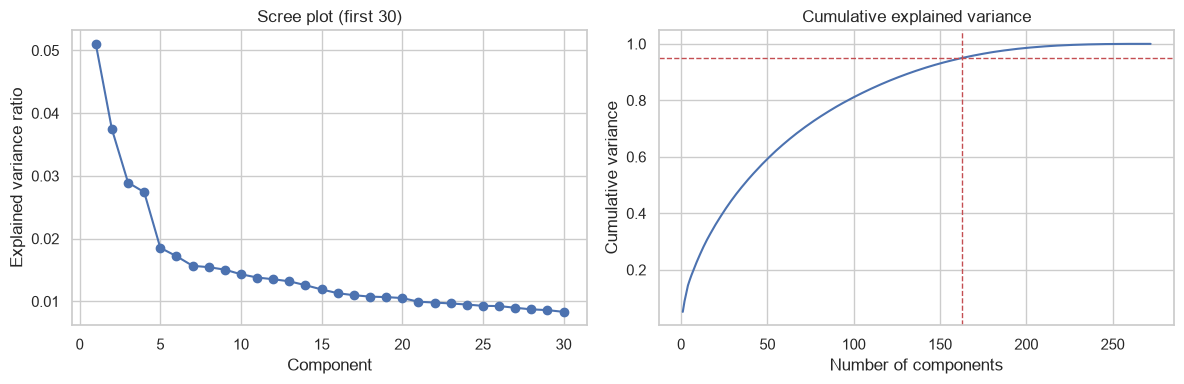

full_features  AP 0.166 (+/- 0.080)
pca_95         AP 0.133 (+/- 0.053)
best CV AP: 0.175  {'model__C': 1.0, 'pca__n_components': 20}
test AP: 0.153 (baseline 0.067)


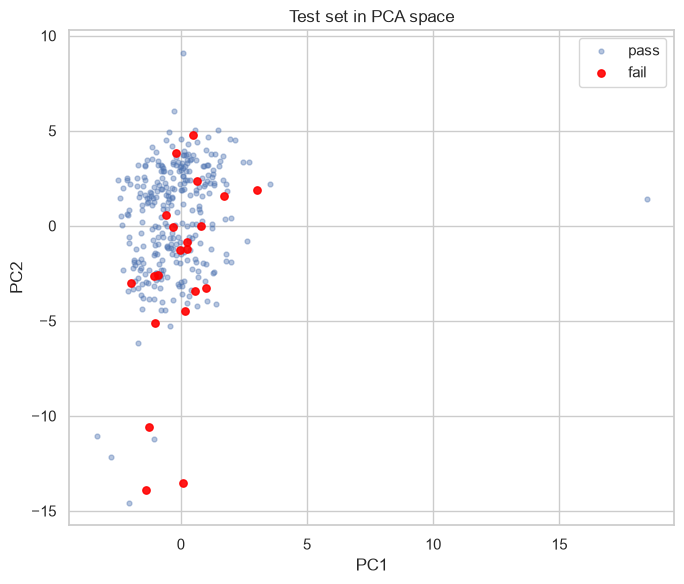

Sensors loading most heavily on PC1:
sensor_196    0.256204
sensor_207    0.249606
sensor_199    0.249273
sensor_204    0.242290
sensor_197    0.235861
sensor_336    0.235267
sensor_203    0.232190
sensor_471    0.231412
sensor_205    0.229853
sensor_67     0.224882
Name: PC1, dtype: float64


In [6]:
# =============================================================================
# PIPELINE 4 — HIGH-DIMENSIONAL: PCA on SECOM's 591 sensors
# =============================================================================

# ---- 1. Load and clean (same as Pipeline 3) ---------------------------------
df_secom = pd.read_csv(SECOM_PATH)

non_feature_cols = ["Time", "Pass/Fail"]
sensor_cols = [c for c in df_secom.columns if c not in non_feature_cols]

X_raw = df_secom[sensor_cols].copy()
X_raw.columns = [f"sensor_{i}" for i in range(X_raw.shape[1])]
y = (df_secom["Pass/Fail"] == 1).astype(int)

X_clean = X_raw.loc[:, X_raw.isna().mean() < 0.5]
print(f"{X_raw.shape[1]} sensors -> {X_clean.shape[1]} after dropping mostly-empty")

# ---- 2. Correlation filter --------------------------------------------------
# Keep one sensor from each group of near-duplicates. Uses no target information.
corr = X_clean.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant = [c for c in upper.columns if any(upper[c] > 0.95)]
X_clean = X_clean.drop(columns=redundant)
print(f"dropped {len(redundant)} correlated sensors -> {X_clean.shape[1]} remain")

# ---- 3. Split ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# ---- 4. Inspect the variance structure before committing to n_components ----
# Standalone PCA fit on training data only, purely to read the scree curve.
explore = Pipeline([
    ("impute",   SimpleImputer(strategy="median")),
    ("scale",    StandardScaler()),   # PCA without scaling is dominated by large-range sensors
    ("variance", VarianceThreshold(threshold=0.0)),
    ("pca",      PCA(random_state=RANDOM_STATE)),
]).fit(X_train)

evr = explore.named_steps["pca"].explained_variance_ratio_
cumulative = np.cumsum(evr)
n_for_95 = np.argmax(cumulative >= 0.95) + 1
print(f"{n_for_95} components capture 95% of the variance "
      f"(from {X_train.shape[1]} sensors)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, 31), evr[:30], "o-")
axes[0].set(xlabel="Component", ylabel="Explained variance ratio",
            title="Scree plot (first 30)")
axes[1].plot(range(1, len(cumulative) + 1), cumulative)
axes[1].axhline(0.95, color="r", ls="--", lw=1)
axes[1].axvline(n_for_95, color="r", ls="--", lw=1)
axes[1].set(xlabel="Number of components", ylabel="Cumulative variance",
            title="Cumulative explained variance")
plt.tight_layout(); plt.show()

# ---- 5. Compare: full features vs PCA ---------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

full_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("model",  LogisticRegression(max_iter=3000, class_weight="balanced",
                                  random_state=RANDOM_STATE)),
])

pca_pipe = Pipeline([
    ("impute",   SimpleImputer(strategy="median")),
    ("scale",    StandardScaler()),
    ("variance", VarianceThreshold(threshold=0.0)),
    ("pca",      PCA(n_components=0.95, random_state=RANDOM_STATE)),  # float = keep 95% variance
    ("model",    LogisticRegression(max_iter=3000, class_weight="balanced",
                                    random_state=RANDOM_STATE)),
])

for name, pipe in {"full_features": full_pipe, "pca_95": pca_pipe}.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="average_precision", n_jobs=-1)
    print(f"{name:14s} AP {scores.mean():.3f} (+/- {scores.std():.3f})")

# ---- 6. Tune the number of components jointly with the model ---------------
# n_components is a hyperparameter like any other — do not fix it by eye.
param_grid = {
    "pca__n_components": [10, 20, 40, 80],
    "model__C":          [0.01, 0.1, 1.0],   # inverse regularisation: smaller = stronger
}

search = GridSearchCV(pca_pipe, param_grid, cv=cv,
                      scoring="average_precision", n_jobs=-1)
search.fit(X_train, y_train)
print(f"best CV AP: {search.best_score_:.3f}  {search.best_params_}")
best_model = search.best_estimator_

# ---- 7. Evaluate ------------------------------------------------------------
y_proba = best_model.predict_proba(X_test)[:, 1]
print(f"test AP: {average_precision_score(y_test, y_proba):.3f} "
      f"(baseline {y_test.mean():.3f})")

# ---- 8. Visualise the data in the first two components ----------------------
Z = best_model[:-1].transform(X_test)    # every step except the final classifier
plt.figure(figsize=(7, 6))
plt.scatter(Z[y_test == 0, 0], Z[y_test == 0, 1], s=12, alpha=0.4, label="pass")
plt.scatter(Z[y_test == 1, 0], Z[y_test == 1, 1], s=28, alpha=0.9,
            c="red", label="fail")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Test set in PCA space")
plt.legend(); plt.tight_layout(); plt.show()

# ---- 9. Trace components back to original sensors ---------------------------
# Loadings tell you which sensors a component is built from — the bridge back
# to something a process engineer can act on.
pca_step = best_model.named_steps["pca"]
kept_mask = best_model.named_steps["variance"].get_support()
kept_names = X_train.columns[kept_mask]

loadings = pd.DataFrame(
    pca_step.components_[:3].T, index=kept_names, columns=["PC1", "PC2", "PC3"]
)
print("Sensors loading most heavily on PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(10))

## Reading the output

**Scree plot** — the elbow marks where extra components stop buying much variance.
`n_components=0.95` lets sklearn pick the count for you; an integer fixes it.

| Outcome | Interpretation |
|---|---|
| PCA matches full features with far fewer dimensions | Redundancy confirmed — keep PCA for speed and stability |
| PCA clearly worse | Discriminative signal lived in a low-variance direction. PCA maximises variance, not class separation — it does not know your target exists |
| PCA clearly better | The full model was overfitting noise |

**Gotcha:** always scale before PCA. Without it, a sensor measuring in thousands
dominates every component regardless of its actual importance.

**Gotcha:** PC1 explaining a large share of variance does **not** mean PC1 predicts the
target. Variance and predictive power are unrelated quantities.

---

# Pipeline 5 — Clustering (HDB market segmentation)

## When to use

| Signal | Reading |
|---|---|
| No target variable at all | Unsupervised |
| You want to *discover* groups, not predict known ones | Clustering |
| You need segment profiles for a stakeholder | KMeans + a profile table |

## What changes versus supervised pipelines

| Aspect | Difference |
|---|---|
| Train/test split | Not needed — nothing is being predicted |
| Scaling | Non-negotiable. KMeans measures Euclidean distance, so unscaled large-range features dominate entirely |
| Choosing k | No ground truth. Use elbow + silhouette + whether the segments make business sense |
| Validation | Silhouette score, and stakeholder judgement |

Clustering uses **all** features simultaneously — each row becomes a point in
p-dimensional space and distance is computed across every dimension at once. That is why
one unscaled feature can hijack the whole result.

(234672, 5)


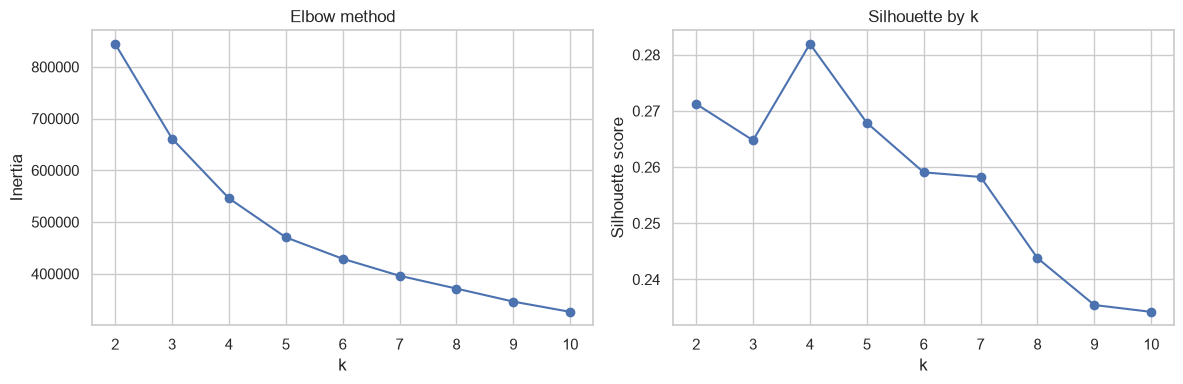

highest silhouette at k=4
        floor_area_sqm        flat_age        storey_mid        price_psm  \
                  mean  count     mean  count       mean  count      mean   
cluster                                                                     
0                 74.1  65348     40.4  65348        6.8  65348    5029.4   
1                 88.9  60600      8.6  60600        9.3  60600    5916.0   
2                119.0  84244     27.9  84244        7.3  84244    4768.5   
3                 99.4  24480     13.6  24480       17.7  24480    8825.6   

               resale_price         
         count         mean  count  
cluster                             
0        65348     370617.0  65348  
1        60600     519586.4  60600  
2        84244     569001.2  84244  
3        24480     863809.8  24480  

Cluster sizes:
cluster
0    65348
1    60600
2    84244
3    24480
Name: count, dtype: int64


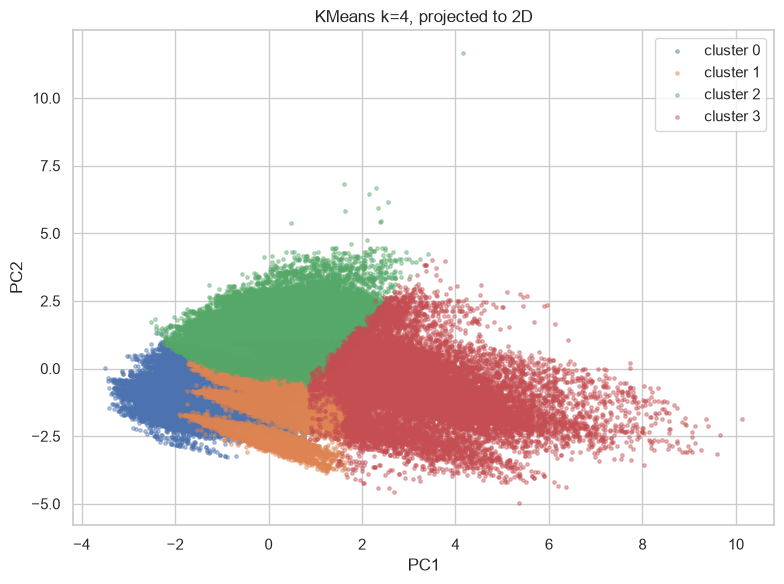

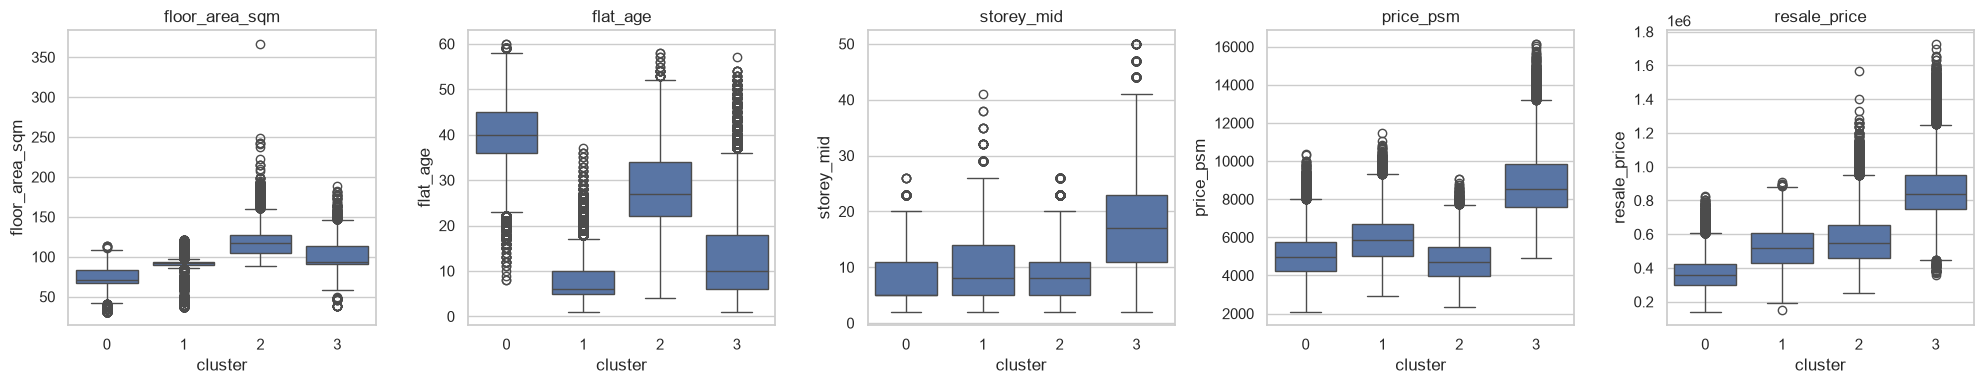

In [7]:
# =============================================================================
# PIPELINE 5 — CLUSTERING: segmenting HDB resale flats
# =============================================================================

# ---- 1. Load and engineer ---------------------------------------------------
df = pd.read_csv(HDB_PATH)
df["month"] = pd.to_datetime(df["month"])
df["flat_age"] = df["month"].dt.year - df["lease_commence_date"]
storey_bounds = df["storey_range"].str.extract(r"(\d+)\s+TO\s+(\d+)").astype(float)
df["storey_mid"] = storey_bounds.mean(axis=1)
df["price_psm"] = df["resale_price"] / df["floor_area_sqm"]

# ---- 2. Choose features — clustering has no target, so this defines everything
# Different feature sets produce different, equally "valid" clusterings.
# Pick features that answer the question you actually care about.
features = ["floor_area_sqm", "flat_age", "storey_mid", "price_psm", "resale_price"]
X = df[features].dropna()
print(X.shape)

# ---- 3. Scale — required, not optional --------------------------------------
# resale_price is in hundreds of thousands, flat_age in tens. Without scaling,
# distance is effectively price alone and the other four features are ignored.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---- 4. Choose k: elbow and silhouette together -----------------------------
k_range = range(2, 11)
inertias, silhouettes = [], []

# Silhouette is O(n^2) — sample for speed on large datasets.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_scaled), size=min(5000, len(X_scaled)), replace=False
)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)     # within-cluster sum of squares — always falls with k
    silhouettes.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, "o-")
axes[0].set(xlabel="k", ylabel="Inertia", title="Elbow method")
axes[1].plot(k_range, silhouettes, "o-")
axes[1].set(xlabel="k", ylabel="Silhouette score", title="Silhouette by k")
plt.tight_layout(); plt.show()

best_k = k_range[int(np.argmax(silhouettes))]
print(f"highest silhouette at k={best_k}")

# ---- 5. Fit the final model -------------------------------------------------
K = 4   # override with a business-sensible number if the metrics are ambiguous
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(X_scaled)

X_labelled = X.copy()
X_labelled["cluster"] = labels

# ---- 6. Profile the clusters — this IS the deliverable ----------------------
# A cluster number means nothing until you can describe it in plain language.
profile = X_labelled.groupby("cluster").agg(["mean", "count"]).round(1)
print(profile)

print("\nCluster sizes:")
print(X_labelled["cluster"].value_counts().sort_index())

# ---- 7. Visualise in 2D via PCA ---------------------------------------------
# PCA is used here purely for plotting — the clustering happened in 5D.
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for c in range(K):
    mask = labels == c
    plt.scatter(coords[mask, 0], coords[mask, 1], s=6, alpha=0.4, label=f"cluster {c}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"KMeans k={K}, projected to 2D")
plt.legend(); plt.tight_layout(); plt.show()

# ---- 8. Compare clusters on each feature ------------------------------------
fig, axes = plt.subplots(1, len(features), figsize=(4 * len(features), 4))
for ax, feat in zip(axes, features):
    sns.boxplot(data=X_labelled, x="cluster", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout(); plt.show()

## Reading the output

| Silhouette score | Reading |
|---|---|
| Above 0.7 | Strong, well-separated structure |
| 0.5 – 0.7 | Reasonable structure |
| 0.25 – 0.5 | Weak — clusters overlap heavily |
| Below 0.25 | No meaningful cluster structure found |

Real tabular business data often lands in the 0.2–0.4 range. That does not make the
segments useless; it means the boundaries are soft.

**Elbow versus silhouette.** Inertia always decreases as k rises, so it can never pick k
alone — you are looking for the bend. Silhouette actually has a maximum. When the two
disagree, the tiebreaker is whether you can name the segments in a sentence a stakeholder
would recognise.

**Gotcha:** KMeans assumes roughly spherical, similarly sized clusters. If the boxplots
show one cluster containing 95% of rows, try DBSCAN (density-based, finds arbitrary
shapes, and labels outliers as `-1`).

**Gotcha:** re-running with a different `random_state` and getting different clusters
means the structure is unstable. `n_init=10` runs ten initialisations and keeps the best.

---

# Pipeline 6 — Anomaly detection (SECOM sensor readings)

## When to use

| Signal | Reading |
|---|---|
| Anomalies are rare and not exhaustively labelled | Supervised classification would starve for positives |
| New failure modes appear that were never labelled | An unsupervised detector flags "weird", not "matches known defect" |
| You need a monitoring alarm rather than a prediction | Score every incoming row, alert above a threshold |

## Anomaly detection versus imbalanced classification

Both hunt for rare events. The difference is what they learn:

| | Imbalanced classification (P3) | Anomaly detection (P6) |
|---|---|---|
| Needs labels | Yes | No |
| Learns | What known defects look like | What normal looks like |
| Catches novel failure modes | No | Yes |
| Typically more precise | Yes | No |

If you have reliable labels, classify. Reach for anomaly detection when labels are
missing, unreliable, or when unknown failure modes are the real concern.

## `contamination` is the key parameter

It tells the model what fraction of the data to treat as anomalous, which sets the score
cutoff. Set it from domain knowledge (a known defect rate), not by guessing.

(1567, 446), true anomaly rate 6.637%
IsolationForest flagged 104 rows
LOF             flagged 104 rows
both agreed on         42 rows


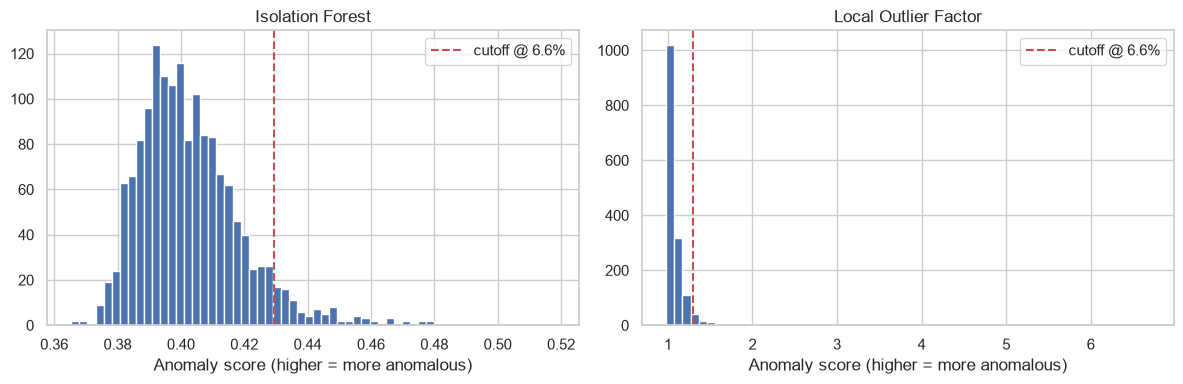

IsolationForest  precision 0.144 | recall 0.144 | lift 2.17x | AP 0.119
LOF              precision 0.135 | recall 0.135 | lift 2.03x | AP 0.092

Random-guess baseline precision: 0.066


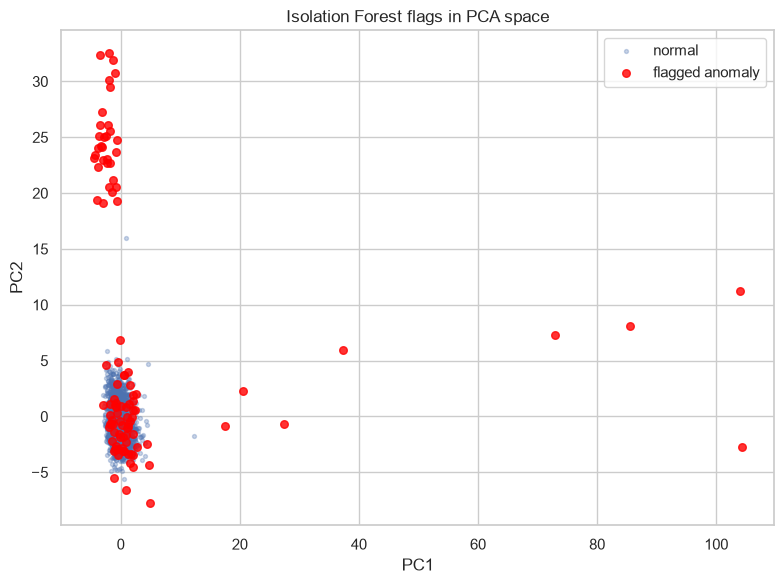


Row 2 — sensors furthest from their mean (in std devs):
sensor_567    6.59
sensor_565    6.47
sensor_558    6.05
sensor_569    5.15
sensor_510    4.91
sensor_38     4.71
sensor_587    3.63
sensor_588    3.32
sensor_55     3.11
sensor_586    2.99
dtype: float64


In [8]:
# =============================================================================
# PIPELINE 6 — ANOMALY DETECTION: flagging unusual SECOM sensor readings
# =============================================================================

# ---- 1. Load ----------------------------------------------------------------
df_secom = pd.read_csv(SECOM_PATH)

non_feature_cols = ["Time", "Pass/Fail"]
sensor_cols = [c for c in df_secom.columns if c not in non_feature_cols]

X_raw = df_secom[sensor_cols].copy()
X_raw.columns = [f"sensor_{i}" for i in range(X_raw.shape[1])]
y_true = (df_secom["Pass/Fail"] == 1).astype(int)   # held aside for evaluation ONLY

X_clean = X_raw.loc[:, X_raw.isna().mean() < 0.5]
X_clean = X_clean.loc[:, X_clean.nunique(dropna=True) > 1]
print(f"{X_clean.shape}, true anomaly rate {y_true.mean():.3%}")

# ---- 2. Preprocess ----------------------------------------------------------
# No train/test split: the model is not learning a target, and in production you
# fit on a window of recent normal-operation data and score everything after it.
prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),   # distance-based methods need comparable ranges
])
X_prep = prep.fit_transform(X_clean)

CONTAMINATION = 0.066    # set from the known fab defect rate, not guessed

# ---- 3. Isolation Forest ----------------------------------------------------
# Isolates points via random splits. Anomalies need fewer splits to isolate,
# so they sit closer to the root. Handles high dimensions well.
iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,   # sets the cutoff on the score distribution
    max_samples="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso_pred  = iso.fit_predict(X_prep)          # returns -1 (anomaly) or 1 (normal)
iso_score = -iso.score_samples(X_prep)       # negate so HIGHER = more anomalous
iso_flag  = (iso_pred == -1).astype(int)

# ---- 4. Local Outlier Factor ------------------------------------------------
# Compares each point's local density to its neighbours' — catches anomalies that
# are only unusual relative to their local region, which Isolation Forest can miss.
lof = LocalOutlierFactor(
    n_neighbors=20,                 # smaller = more sensitive to local structure
    contamination=CONTAMINATION,
    novelty=False,                  # False = score the training data itself
    n_jobs=-1,
)
lof_pred  = lof.fit_predict(X_prep)
lof_score = -lof.negative_outlier_factor_
lof_flag  = (lof_pred == -1).astype(int)

print(f"IsolationForest flagged {iso_flag.sum()} rows")
print(f"LOF             flagged {lof_flag.sum()} rows")
print(f"both agreed on         {(iso_flag & lof_flag).sum()} rows")

# ---- 5. Score distributions -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, score, flag) in zip(axes, [
    ("Isolation Forest", iso_score, iso_flag),
    ("Local Outlier Factor", lof_score, lof_flag),
]):
    ax.hist(score, bins=60)
    ax.axvline(np.quantile(score, 1 - CONTAMINATION), color="r", ls="--",
               label=f"cutoff @ {CONTAMINATION:.1%}")
    ax.set(xlabel="Anomaly score (higher = more anomalous)", title=name)
    ax.legend()
plt.tight_layout(); plt.show()

# ---- 6. Sanity-check against labels -----------------------------------------
# In production you would not have these. Here they answer one question:
# does "statistically weird" overlap at all with "actually defective"?
for name, flag, score in [("IsolationForest", iso_flag, iso_score),
                          ("LOF", lof_flag, lof_score)]:
    tp = ((flag == 1) & (y_true == 1)).sum()
    precision_at_k = tp / max(flag.sum(), 1)
    recall_at_k    = tp / y_true.sum()
    lift           = precision_at_k / y_true.mean()
    print(f"{name:16s} precision {precision_at_k:.3f} | recall {recall_at_k:.3f} | "
          f"lift {lift:.2f}x | AP {average_precision_score(y_true, score):.3f}")

print(f"\nRandom-guess baseline precision: {y_true.mean():.3f}")

# ---- 7. Visualise flagged points in PCA space -------------------------------
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_prep)
plt.figure(figsize=(8, 6))
plt.scatter(coords[iso_flag == 0, 0], coords[iso_flag == 0, 1],
            s=8, alpha=0.3, label="normal")
plt.scatter(coords[iso_flag == 1, 0], coords[iso_flag == 1, 1],
            s=30, c="red", alpha=0.8, label="flagged anomaly")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Isolation Forest flags in PCA space")
plt.legend(); plt.tight_layout(); plt.show()

# ---- 8. Which sensors drove a specific flag? --------------------------------
# Isolation Forest gives no native feature attribution. A practical proxy:
# report the sensors with the largest standardised deviation for that row.
flagged_idx = np.where(iso_flag == 1)[0]
row = flagged_idx[0]

deviation = pd.Series(np.abs(X_prep[row]), index=X_clean.columns)
print(f"\nRow {row} — sensors furthest from their mean (in std devs):")
print(deviation.sort_values(ascending=False).head(10).round(2))

## Reading the output

| Output | Reading |
|---|---|
| Lift | Precision divided by the base rate. Lift of 2× means flagged rows are twice as likely to be defective as a random row. |
| Agreement between methods | Rows both methods flag are the highest-confidence anomalies. Investigate those first. |
| Bimodal score histogram | A clean separation — good. A smooth unimodal curve means the cutoff is somewhat arbitrary. |

**Expect modest numbers.** Anomaly detection finds *statistical* outliers. Not every
defect is statistically unusual, and not every unusual reading is a defect. Lift above
1.5× is already useful for prioritising inspection.

**Gotcha:** `fit_predict` on `LocalOutlierFactor` with `novelty=False` cannot score new
data. To deploy it as a live detector, set `novelty=True`, call `fit()` on normal data,
then `predict()` on new rows.

**Gotcha:** the sign conventions are inconsistent across sklearn. `predict` returns
`-1` for anomalies but `score_samples` returns *lower* values for anomalies. Negate the
scores so higher always means more anomalous, as above.

---

# 99 — Building blocks

Reusable fragments that appear across every pipeline above.

## Cross-validation strategy

| Strategy | Use when | Notes |
|---|---|---|
| `KFold` | Regression, independent rows | Set `shuffle=True` unless data is ordered |
| `StratifiedKFold` | Any classification | Preserves class ratio per fold — mandatory when imbalanced |
| `GroupKFold` | Rows cluster into groups (same wafer, same lot, same customer) | Prevents the same group appearing in train and test |
| `TimeSeriesSplit` | Predicting forward in time | Never shuffle — training must precede test chronologically |
| `RepeatedStratifiedKFold` | Small datasets, noisy scores | Repeats the whole CV with new splits |

## Hyperparameter search

| Method | How it works | Best for |
|---|---|---|
| `GridSearchCV` | Tries every combination | Few parameters, small grid, exhaustive coverage needed |
| `RandomizedSearchCV` | Samples `n_iter` combinations | Large space, unknown which parameters matter |
| Optuna | Bayesian — each trial informs the next | Expensive models, large space, limited compute budget |

Rough rule: under about 50 combinations, use grid; above that, random or Optuna.

## Metric selection

| Task | Default metric | Switch to | When |
|---|---|---|---|
| Regression | RMSE | MAE | Outliers should not dominate |
| Regression | RMSE | MAPE | Relative error matters more than absolute |
| Classification, balanced | ROC-AUC | Accuracy | Simple reporting to non-technical stakeholders |
| Classification, imbalanced | Average precision | Recall @ fixed precision | A specific catch rate is required |
| Clustering | Silhouette | Davies-Bouldin | Cross-checking a silhouette result |

## Preventing leakage — the checklist

| Rule | Why |
|---|---|
| Split before fitting anything | Imputer medians and scaler statistics must come from training data only |
| Put every transform inside a `Pipeline` | Guarantees each CV fold refits transforms from scratch |
| Resample inside `imblearn.pipeline.Pipeline` | SMOTE applied before splitting leaks synthetic test rows into training |
| Any step that uses `y` goes inside CV | Feature selection by target correlation is a classic leak |
| Touch the test set once, at the very end | Tuning against test scores turns it into a second training set |

## The pattern for pulling components out of a fitted pipeline

Useful for interpretation, and easy to forget.

In [ ]:
# Access a named step
model = best_model.named_steps["model"]

# Every step except the last (i.e. all preprocessing) — returns transformed X
X_transformed = best_model[:-1].transform(X_test)

# Feature names after a ColumnTransformer with OneHotEncoder
feature_names = best_model.named_steps["prep"].get_feature_names_out()

# Which columns survived a VarianceThreshold
kept = best_model.named_steps["variance"].get_support()

# Full parameter list, showing the exact "step__param" keys usable in a search grid
best_model.get_params().keys()

## The universal skeleton

Every supervised pipeline in this notebook is the same nine steps:

| # | Step | Non-negotiable rule |
|---|---|---|
| 1 | Load | Check `.shape` and `.dtypes` immediately |
| 2 | Engineer features | Derived columns before splitting is fine if they use no target |
| 3 | Define X and y | Separate numeric and categorical lists explicitly |
| 4 | **Split** | Before anything is fitted. Stratify for classification. |
| 5 | Build the preprocessor | Impute before scale; `handle_unknown="ignore"` on encoders |
| 6 | Baseline | A simple model first, so you know what tuning actually bought |
| 7 | Compare families | Cheap CV across two or three candidates |
| 8 | Tune the winner | Grid, random, or Optuna — scoring on the metric that matters |
| 9 | Evaluate and interpret | Test set once; then residuals, confusion matrix, importances |

Unsupervised pipelines (5 and 6) drop steps 3, 4, and 6, and replace step 9 with profile
tables and score distributions.